Customer churn Prediction

In [61]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split


In [74]:
df = pd.read_csv("data/processed/cleaned_telco.csv")

In [75]:
df.head()

,Customer ID,Gender,Age,Under 30,Senior Citizen,Married,Dependents,Number of Dependents,Country,State,...,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Satisfaction Score,Customer Status,Churn Label,Churn Score,CLTV,Churn Category,Churn Reason
0,8779-QRDMV,Male,78,No,Yes,No,No,0,United States,California,...,20,0.00,59.65,3,Churned,Yes,91,5433,Competitor,Competitor offered more data
1,7495-OOKFY,Female,74,No,Yes,Yes,Yes,1,United States,California,...,0,390.80,1024.10,3,Churned,Yes,69,5302,Competitor,Competitor made better offer
2,1658-BYGOY,Male,71,No,Yes,No,Yes,3,United States,California,...,0,203.94,1910.88,2,Churned,Yes,81,3179,Competitor,Competitor made better offer
3,4598-XLKNJ,Female,78,No,Yes,Yes,Yes,1,United States,California,...,0,494.00,2995.07,2,Churned,Yes,88,5337,Dissatisfaction,Limited range of services
4,4846-WHAFZ,Female,80,No,Yes,Yes,Yes,1,United States,California,...,0,234.21,3102.36,2,Churned,Yes,67,2793,Price,Extra data charges


In [83]:
df["Churn Label"].value_counts(dropna=False)


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

In [82]:
df["Churn_Flag"] = df["Churn Label"].apply(
    lambda x: 1 if x == "Yes" else 0
)

In [78]:
df["Churn_Flag"] = (df["Churn Label"].map({
    "NO":0,
    "Yes":1
}))

In [84]:
df["Churn_Flag"].value_counts(dropna=False)

Churn_Flag
0    5174
1    1869
Name: count, dtype: int64

In [85]:
#drop leqkage variables
df = df.drop(
    columns=[
        "Customer Status",
        "Churn Label",
        "Churn Score",
        "Churn Category",
        "Churn Reason"
    ]
)

In [86]:
#Feature Variables
features = [
    "Age",
    "Gender",
    "Married",
    "Dependents",
    "Number of Dependents",
    "Tenure in Months",
    "Offer",
    "Internet Type",
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Unlimited Data",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charge",
    "Total Revenue",
    "Satisfaction Score",
    "CLTV",
    "Referred a Friend",
    "Number of Referrals"
]

X = df[features]

# Convert categorical variables
X = pd.get_dummies(
    X,
    drop_first=True
)

# Target
y = df["Churn_Flag"]

In [87]:
print(X.shape)

(7043, 33)


In [88]:
print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (7043, 33)
Target Shape: (7043,)


In [89]:
X.head()

,Age,Number of Dependents,Tenure in Months,Monthly Charge,Total Revenue,Satisfaction Score,CLTV,Number of Referrals,Gender_Male,Married_Yes,...,Streaming TV_Yes,Streaming Movies_Yes,Streaming Music_Yes,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check,Referred a Friend_Yes
0,78,0,1,39.65,59.65,3,5433,0,True,False,...,False,True,False,False,False,False,True,False,False,False
1,74,1,8,80.65,1024.10,3,5302,1,False,True,...,False,False,False,True,False,False,True,True,False,True
2,71,3,18,95.45,1910.88,2,3179,0,True,False,...,True,True,True,True,False,False,True,False,False,False
3,78,1,25,98.50,2995.07,2,5337,1,False,True,...,True,True,False,True,False,False,True,False,False,True
4,80,1,37,76.50,3102.36,2,2793,1,False,True,...,False,False,False,True,False,False,True,False,False,True


Some of the input variables were categories (like names or labels), which machine learning models can’t use directly.

So, we converted them into numbers using a method called one-hot encoding with pandas get_dummies().

We used drop_first=True to remove one category from each group, which helps avoid duplicate or unnecessary information.


In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

The dataset was split into two parts: 80% for training the model and 20% for testing it. A fixed random state of 42 was used so that the results can be reproduced. Stratified sampling was applied to keep the same proportion of churned and retained customers in both the training and testing sets. This helps ensure a fair and reliable evaluation of the model on new data.

In [92]:
from sklearn.linear_model import LogisticRegression

In [93]:
#train
log_model = LogisticRegression(
    max_iter = 5000
)
log_model.fit(
    X_train,
    y_train
)

/Users/laxmisatyal/Desktop/miniconda3/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=5000)

In [94]:
#prediction 
y_pred = log_model.predict(X_test)

In [110]:
#evaluate 
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

logistic_accuracy = accuracy_score(
    y_test,
    y_pred
)

print("Logistic Regression Accuracy:")
print(logistic_accuracy)

Logistic Regression Accuracy:
0.9623846699787083


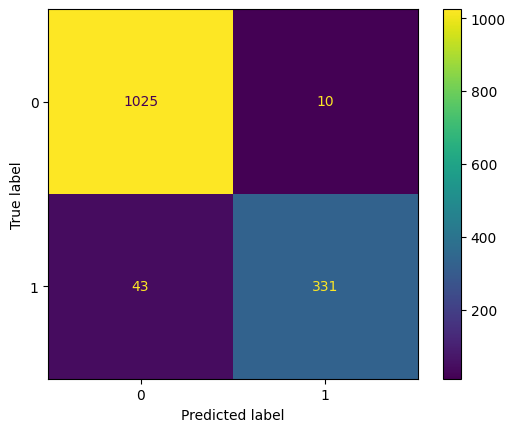

In [96]:
#confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)



In [97]:
#Random Forest 
from sklearn.ensemble import RandomForestClassifier 

In [99]:
#train
rf = RandomForestClassifier(
    random_state = 42)
rf.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [100]:
#predict
rf_pred = rf.predict(
    X_test
)

In [111]:
#evaluate 
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:")
print(rf_accuracy)


Random Forest Accuracy:
0.9559971611071683


In [102]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      1035
           1       0.97      0.86      0.91       374

    accuracy                           0.96      1409
   macro avg       0.96      0.93      0.94      1409
weighted avg       0.96      0.96      0.96      1409



In [103]:
#ROC Curve
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)

rf_probs = rf.predict_proba(
    X_test
)[:,1]

auc = roc_auc_score(
    y_test,
    rf_probs
)

print(auc)

0.9842078069699554


In [108]:
#feature importance 
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending = False
)
importance.head(15)

,Feature,Importance
5,Satisfaction Score,0.497654
2,Tenure in Months,0.069002
4,Total Revenue,0.054022
3,Monthly Charge,0.050296
7,Number of Referrals,0.039132
28,Contract_Two Year,0.037068
0,Age,0.035721
6,CLTV,0.033063
17,Internet Type_Fiber Optic,0.022359
27,Contract_One Year,0.014430


In [113]:
#model comparison
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy (%)": [
        round(logistic_accuracy * 100, 2),
        round(rf_accuracy * 100, 2)
    ]
})

results

,Model,Accuracy (%)
0,Logistic Regression,96.24
1,Random Forest,95.60


## Business Impact

The churn prediction model achieved **96.24% accuracy** and an **AUC of 0.984**, demonstrating strong potential to identify at-risk customers and support proactive retention strategies.